In [30]:
# Globals
import numpy as np

from shared_util.pipelines import ModelPipeline
import warnings
warnings.filterwarnings('ignore')

METRICS_DB_ID = 1
METRICS_NOTES = "None"

UPDATE_DATABASE = True

LOG_TRANSFORM_COLS = np.array(
    ['number_outpatient', 'number_inpatient', 'number_emergency', 
     'num_medications', 'num_procedures', 'time_in_hospital'
     ])

# Results

In [32]:
from shared_util.fetch import fetch_metric

results_df = fetch_metric(run_id=METRICS_DB_ID).sort_values(by='roc_auc', ascending=False)


results_df[results_df['data'] == 'test'].head(5)

,id,run_id,model,data,threshold_notes,pipeline_notes,hyperparam_notes,notes,roc_auc,accuracy,precision,recall,f1,tn,tp,fp,fn,created_at
0,35,1,xgb,test,f2_weighted,under_sample,tuned_best_roc_auc,None,0.675963,0.472337,0.128680,0.767159,0.220392,4709.0,883.0,5979.0,268.0,2025-10-27 23:41:10.147287
11,24,1,rf,test,f2_weighted,under_sample,tuned_best_roc_auc,None,0.674749,0.264465,0.109538,0.920938,0.195789,2071.0,1060.0,8617.0,91.0,2025-10-27 23:23:22.331265
4,31,1,svc,test,f2_weighted,under_sample,tuned_best_roc_auc,None,0.674099,0.418954,0.122263,0.805387,0.212298,4033.0,927.0,6655.0,224.0,2025-10-27 23:36:02.302171
7,28,1,sgd,test,f2_weighted,under_sample,tuned_best_roc_auc,None,0.669999,0.421995,0.122847,0.805387,0.213177,4069.0,927.0,6619.0,224.0,2025-10-27 23:24:32.414371


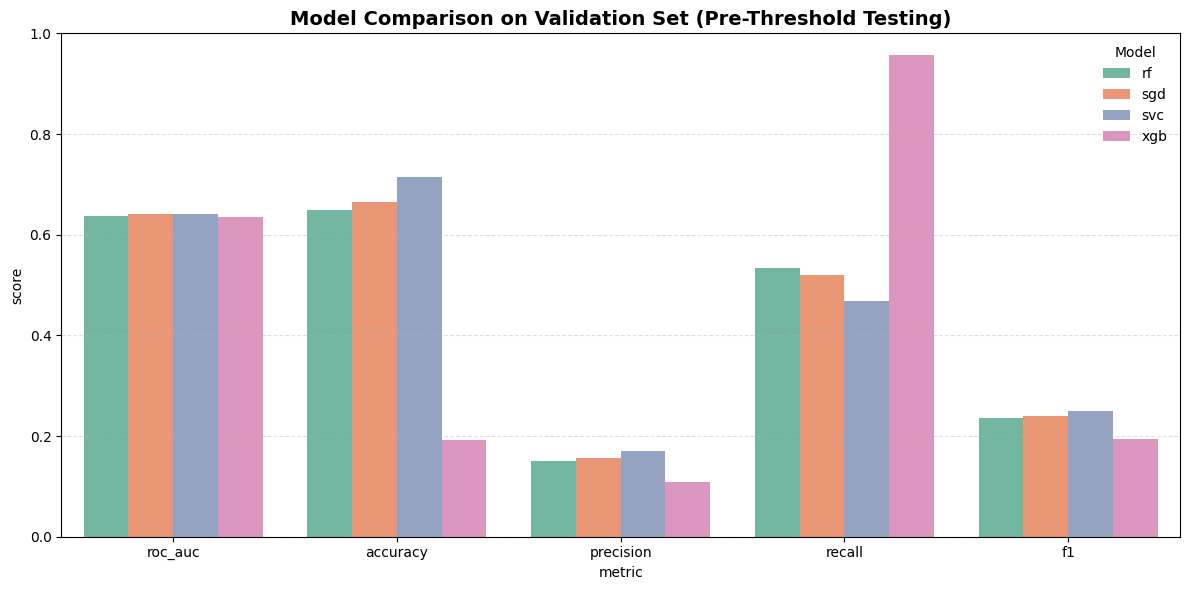

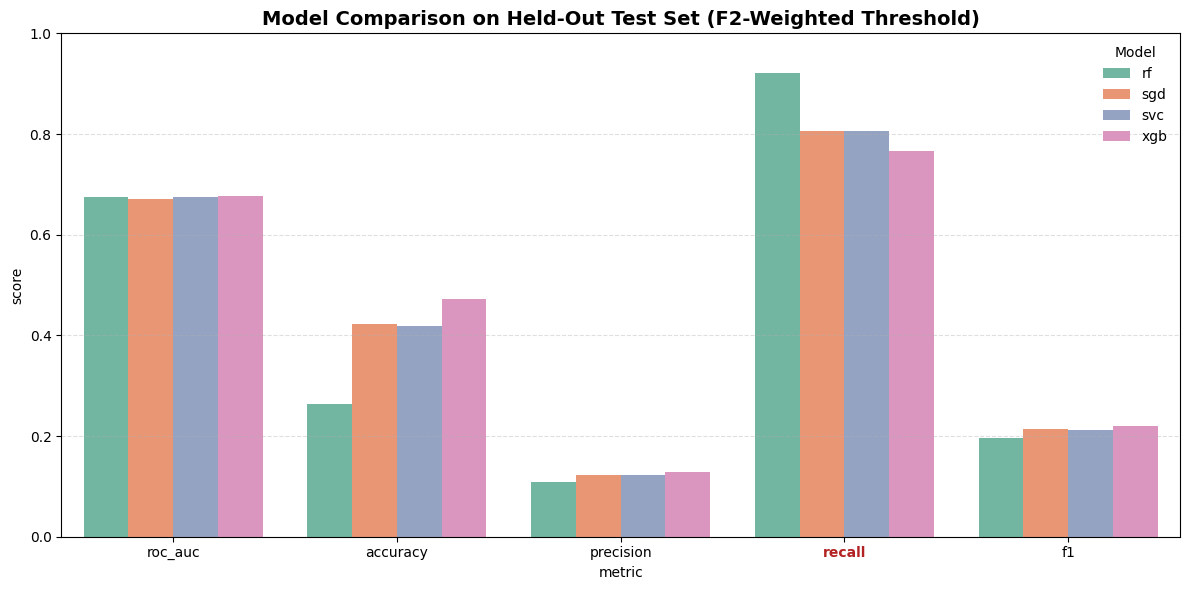

In [33]:
from shared_util.results.results import summary_by_auc, summary_by_recall, plot_metrics

plot_metrics(results_df, METRICS_DB_ID)

In [34]:
summary_by_auc(results_df, plot_id=METRICS_DB_ID)
summary_by_recall(results_df)

Models by ROC_AUC


,model,roc_auc
0,xgb,0.676
1,rf,0.675
2,svc,0.674
3,sgd,0.670


Models by Recall


,model,recall
11,rf,0.921
7,sgd,0.805
4,svc,0.805
0,xgb,0.767


# Random Forest

After reading (Liu, V. et al.) and (Mahmoud, M. et al.) I decided to begin expirementing with random forest models instead of logistic regression models.

In other studies, random forest models were shown to out perform logsitic regression and support vector models likely due to the mix of tabular, categorical, and numerical features

### Define Pipeline

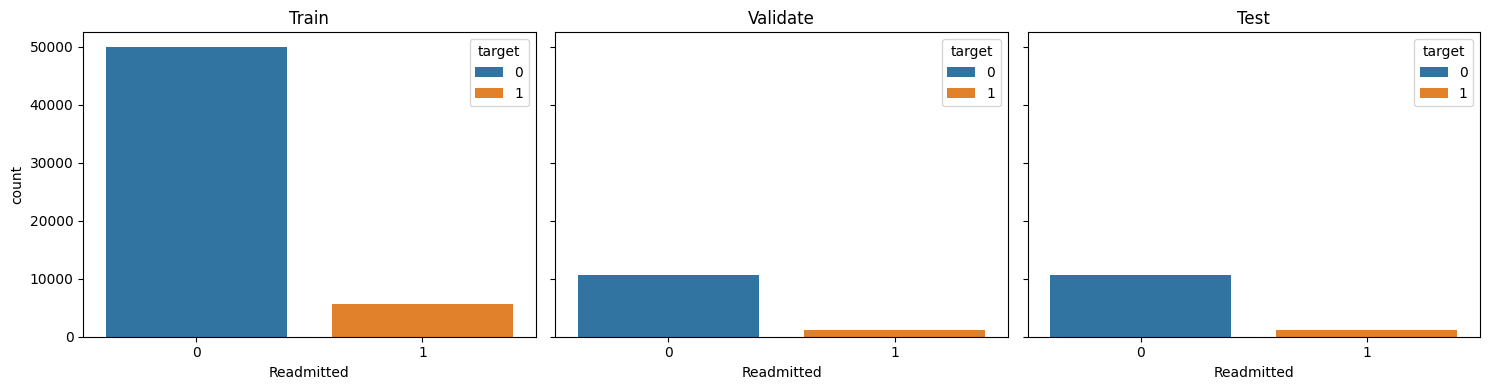

In [5]:

model = 'rf' # Random Forest


model_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,        
    data_path='cleaned',             # csv file name where the data is
    plot_y_dist=True,                # show the target distribution between splits   
    random_state=42,
    log_transform_cols=np.array([]), # no need to transform for tree models
    model=model,
    scale=False,
    group_by_col='patient_nbr',
    create_interactions=False # no interaction terms for tree models
)

### Baseline

Get a baseline before looking at feature importance or hyperparameter tuning

We can use this baseline to check class imbalance approach methods, as well as to get a sense if this model can learn anything from the engineered features

In [6]:
model_pipe.run_baseline(
    run_smote=True,
    run_undersampler=True,
    show_duration_info=True,
)

--------SMOTE Baseline--------
roc_auc score per fold:  [0.593 0.592 0.597 0.6   0.589]
mean roc_auc score: , 0.594
connected to database
-----Undersample Baseline-----
roc_auc score per fold:  [0.654 0.635 0.624 0.653 0.632]
mean roc_auc score: , 0.640
Duration: 0 hrs, 0 mins, 19.0 secs


After several iterations of data cleaning tweaks, baseline SMOTE is performing significantly better with mean ROC of ~0.59

However the random under sampler still outperforms with a mean AUC_ROC of ~0.63

SMOTE performed worse than under sampling so we will stick with under sampling going forward

A mean ROC_AUC score of 0.630 implies that the model has learned something from the data so we will continue analysis.

### Feature Importance

- Tree impurity based importance is naturaly skewed to favor continuous features
- Permutation importance is model agnostic, is uneffected by the large class imbalance, and is not effected by the under sampling technique used

,feature,importance_mean,importance_std
6,number_inpatient,0.067655,0.009661
5,number_emergency,0.006267,0.001169
3,num_medications,0.003834,0.003512
7,number_diagnoses,0.003263,0.003882
0,time_in_hospital,0.002859,0.002259
2,num_procedures,0.002400,0.002274
15,diag1_group_respiratory,0.002164,0.001035
1,num_lab_procedures,0.002108,0.001784
37,specialty_cat_cardiology,0.002038,0.000482
12,diag1_group_musculoskeletal,0.001686,0.000573


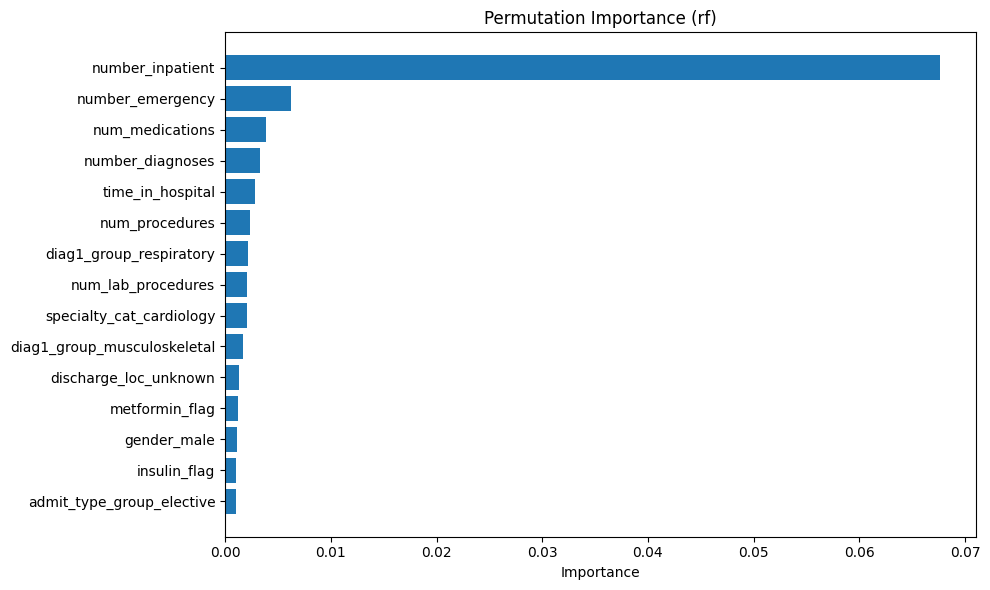

Duration: 0 hrs, 0 mins, 42.3 secs


In [7]:
model_pipe.permute_importance(
    print_num=15,
    plot=True,
    show_duration_info=True
)

In [8]:
param_grid = {
        'model__n_estimators': [100, 200, 500],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10, 15, 20],
        'model__min_samples_leaf': [1, 2, 4, 6, 10],
        'model__max_features': ['sqrt', 'log2', 0.2, 0.5],
        'model__class_weight': [None, 'balanced'],
        'model__bootstrap': [True, False],
        'model__oob_score': [True, False]
    }

model_pipe.run_hyperparam_search(
    hyperparam_dist=param_grid,
    param_scoring='roc_auc',
    n_iter=30,
    n_jobs=-1,
    refit=True,
    show_duration_info=True
)

Best ROC_AUC (cv): 0.658743270492685
Best params: {'model__oob_score': False, 'model__n_estimators': 100, 'model__min_samples_split': 20, 'model__min_samples_leaf': 4, 'model__max_features': 0.2, 'model__max_depth': 10, 'model__class_weight': 'balanced', 'model__bootstrap': True}
logged hyperparameters
Duration: 0 hrs, 0 mins, 32.2 secs


In [9]:
model_pipe.validate(
    show_duration_info=False,
    use_local_model=False
)

# model_pipe.validate(
#     show_duration_info=True,
#     use_local_model=True,
#     oob_score=True,
#     n_estimators=200,
#     min_samples_split=10,
#     min_samples_leaf=4,
#     max_features=0.2,
#     max_depth=10,
#     class_weight='balanced',
#     bootstrap=True
# )

Held out validation metrics: rf
ROC_AUC:     0.6369706741016923
Accuracy:      0.6484578536011429
F1 score:      0.23598173515981735
Precision:     0.15139442231075698
Recall:        0.5347682119205298

Confusion matrix:

TN: 7070, FP: 3621, FN: 562, TP: 646

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.66      0.77     10691
           1       0.15      0.53      0.24      1208

    accuracy                           0.65     11899
   macro avg       0.54      0.60      0.50     11899
weighted avg       0.85      0.65      0.72     11899



Best threshold (F2): 0.3734
Precision: 0.112  Recall: 0.913  F2: 0.376


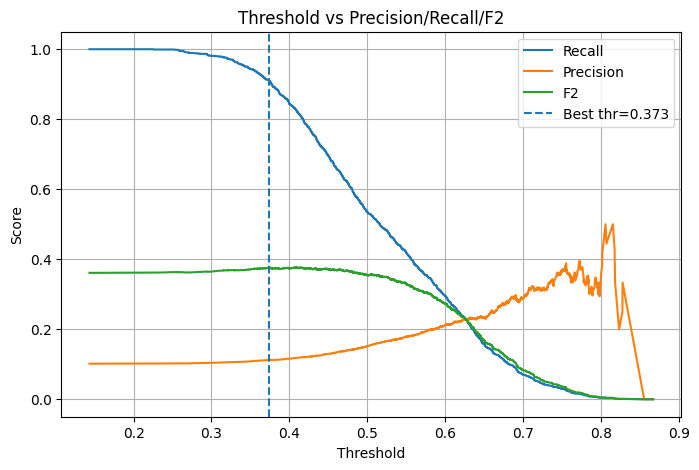

ROC_AUC:     0.674748705239391
Accuracy:      0.2644649041304164
F1 score:      0.1957886959734023
Precision:     0.10953807998346594
Recall:        0.9209383145091226

Confusion matrix:

TN: 2071, FP: 8617, FN: 91, TP: 1060

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.19      0.32     10688
           1       0.11      0.92      0.20      1151

    accuracy                           0.26     11839
   macro avg       0.53      0.56      0.26     11839
weighted avg       0.88      0.26      0.31     11839



In [10]:
model_pipe.test(
    use_f2_threshold=True,
    show_duration_info=False,
    show_plot=True,
    use_local_model=False
)
# model_pipe.test(
#     use_f2_threshold=True,
#     show_duration_info=True,
#     show_plot=True,
#     use_local_model=True,
#     oob_score=True,
#     n_estimators=200,
#     min_samples_split=10,
#     min_samples_leaf=4,
#     max_features=0.2,
#     max_depth=10,
#     class_weight='balanced',
#     bootstrap=True
# )

# Stochastic Gradient Descent Classifier

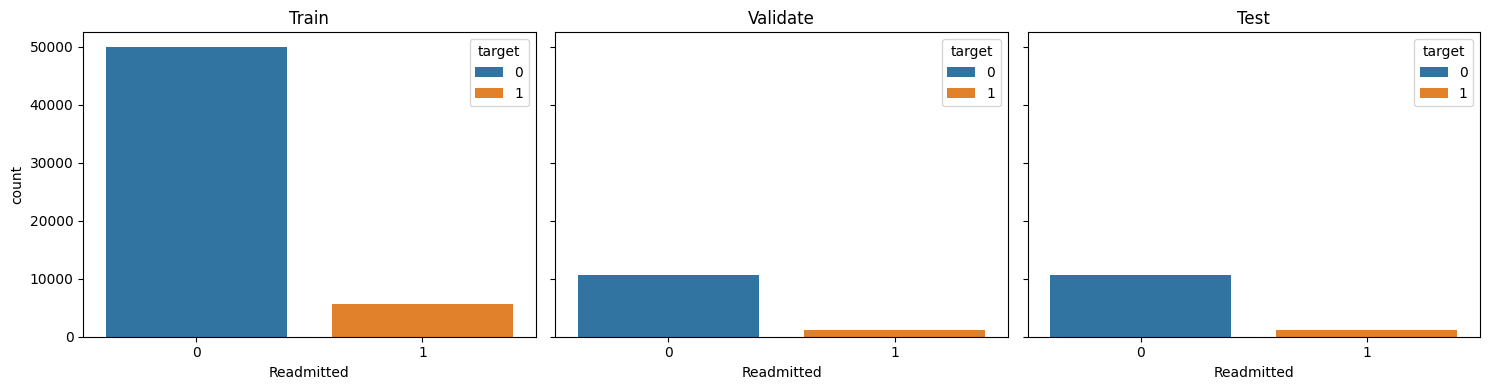

In [11]:
model = 'sgd' #SGDClassifier



sgd_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    model=model,
    scale=True,
)



,feature,importance_mean,importance_std
6,number_inpatient,0.056626,0.010851
5,number_emergency,0.007278,0.002655
0,time_in_hospital,0.005379,0.004363
7,number_diagnoses,0.005019,0.001946
12,diag1_group_musculoskeletal,0.003909,0.001531
3,num_medications,0.003276,0.002170
54,diabetesMed_flag,0.002854,0.001576
58,num_drugs,0.001884,0.001780
4,number_outpatient,0.001430,0.001757
92,i_specialty_cat_pcp__age_group_under_30,0.001311,0.001445


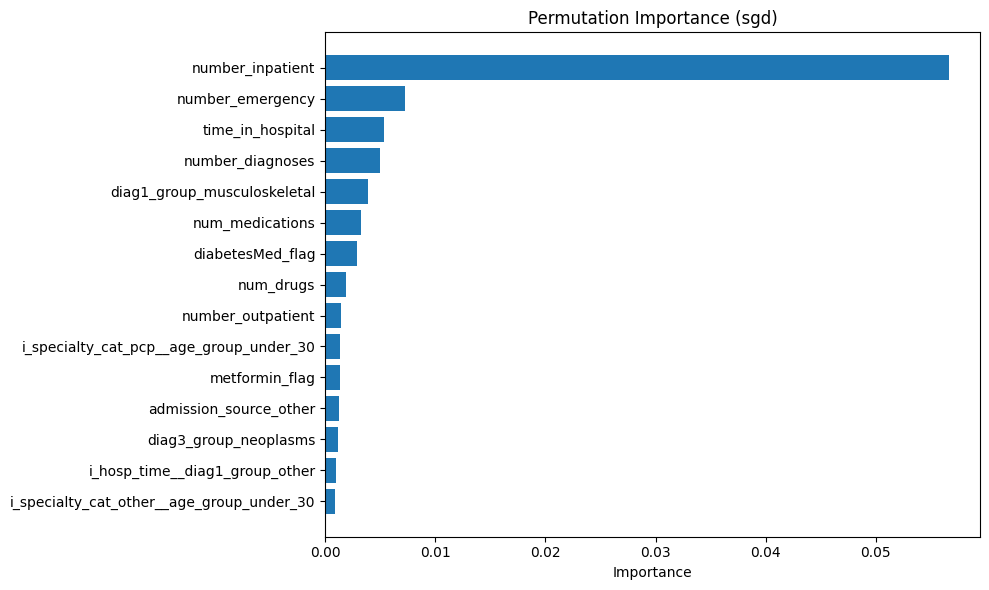

Duration: 0 hrs, 0 mins, 14.6 secs


In [12]:
sgd_pipe.permute_importance()

In [13]:
sgd_pipe.run_baseline() # all true

--------SMOTE Baseline--------
roc_auc score per fold:  [0.577 0.574 0.573 0.566 0.553]
mean roc_auc score: , 0.569
-----Undersample Baseline-----
roc_auc score per fold:  [0.612 0.596 0.607 0.585 0.548]
mean roc_auc score: , 0.590
Duration: 0 hrs, 0 mins, 12.1 secs


In [14]:
sgd_param_grid = {
    "model__loss": ["log_loss", "modified_huber", "hinge", "squared_hinge"],
    "model__penalty": ["l2", "l1", "elasticnet"],
    "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
    "model__l1_ratio": [0.1, 0.5, 0.9],
    "model__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
    "model__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
    "model__max_iter": [100, 500, 1000],
    "model__tol": [1e-3, 1e-4],
    "model__class_weight": [None, "balanced"],
    "model__average": [False, True, 5, 10],
    "model__shuffle": [True],
}

sgd_pipe.run_hyperparam_search(hyperparam_dist=sgd_param_grid)

Best ROC_AUC (cv): 0.6586010604916146
Best params: {'model__tol': 0.0001, 'model__shuffle': True, 'model__penalty': 'l1', 'model__max_iter': 500, 'model__loss': 'modified_huber', 'model__learning_rate': 'invscaling', 'model__l1_ratio': 0.9, 'model__eta0': 0.003, 'model__class_weight': None, 'model__average': 10, 'model__alpha': 0.001}
logged hyperparameters
Duration: 0 hrs, 0 mins, 42.0 secs


In [15]:
sgd_pipe.validate(show_duration_info=False)

Held out validation metrics: sgd
ROC_AUC:     0.6405611484810211
Accuracy:      0.6648457853601143
F1 score:      0.23980175371711782
Precision:     0.15577018325903913
Recall:        0.5206953642384106

Confusion matrix:

TN: 7282, FP: 3409, FN: 579, TP: 629

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.68      0.79     10691
           1       0.16      0.52      0.24      1208

    accuracy                           0.66     11899
   macro avg       0.54      0.60      0.51     11899
weighted avg       0.85      0.66      0.73     11899



Best threshold (F2): 0.4105
Precision: 0.124  Recall: 0.797  F2: 0.382


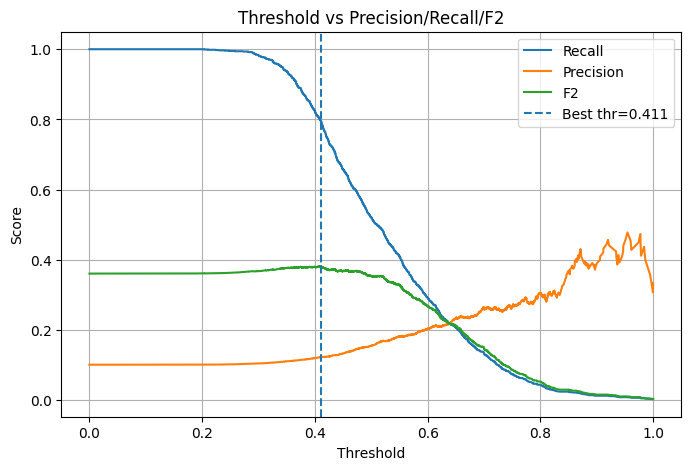

ROC_AUC:     0.6699986213498286
Accuracy:      0.4219951009375792
F1 score:      0.2131769575715764
Precision:     0.12284654121388815
Recall:        0.8053866203301477

Confusion matrix:

TN: 4069, FP: 6619, FN: 224, TP: 927

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.38      0.54     10688
           1       0.12      0.81      0.21      1151

    accuracy                           0.42     11839
   macro avg       0.54      0.59      0.38     11839
weighted avg       0.87      0.42      0.51     11839



In [16]:
sgd_pipe.test(show_duration_info=False)

# Support Vector Classifier

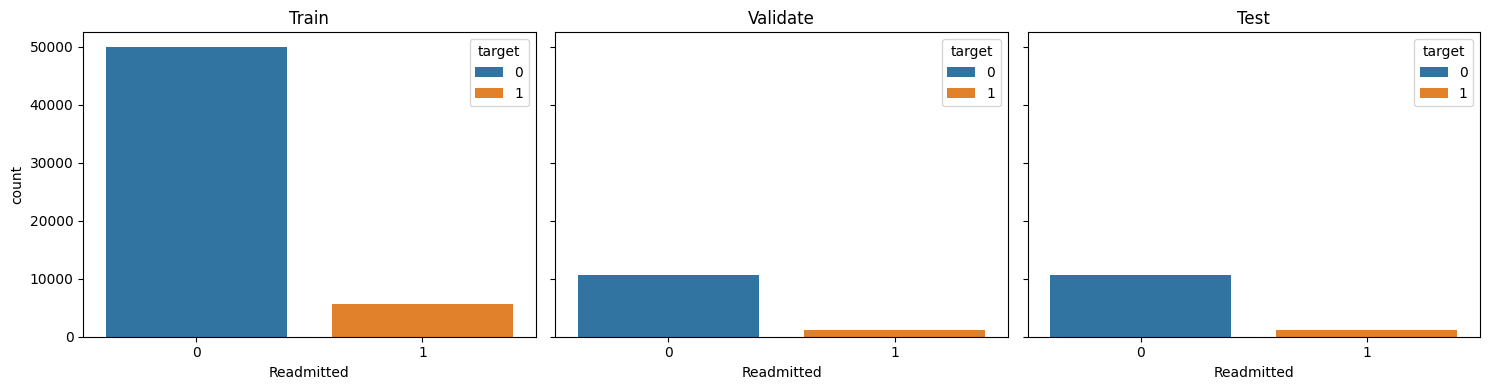

In [17]:
svc_pipe = ModelPipeline(
    model='svc',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scale=True
)

In [18]:
svc_pipe.run_baseline(run_smote=False) # smote did not complete after ~6 hours

-----Undersample Baseline-----
roc_auc score per fold:  [0.643 0.636 0.644 0.661 0.638]
mean roc_auc score: , 0.644
Duration: 0 hrs, 0 mins, 15.1 secs


In [19]:
# slow
# svc_pipe.permute_importance()

In [20]:
from scipy.stats import loguniform


# limited param search due to computation time
svc_param_grid = {
    "model__kernel": ["rbf"],
    "model__C": loguniform(1e-3, 1e3),
    "model__gamma": [0.001, 0.01, 0.1, 1],
    "model__class_weight": ["balanced"],
    "model__shrinking": [False],
}

svc_pipe.run_hyperparam_search(hyperparam_dist=svc_param_grid)

Best ROC_AUC (cv): 0.6583856273938113
Best params: {'model__C': np.float64(0.6317967091932509), 'model__class_weight': 'balanced', 'model__gamma': 0.001, 'model__kernel': 'rbf', 'model__shrinking': False}
logged hyperparameters
Duration: 0 hrs, 10 mins, 50.9 secs


In [21]:
svc_pipe.validate()

Held out validation metrics: svc
ROC_AUC:     0.6407860080367159
Accuracy:      0.7140936213127154
F1 score:      0.24933804060017653
Precision:     0.16997593261131166
Recall:        0.46771523178807944

Confusion matrix:

TN: 7932, FP: 2759, FN: 643, TP: 565

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.74      0.82     10691
           1       0.17      0.47      0.25      1208

    accuracy                           0.71     11899
   macro avg       0.55      0.60      0.54     11899
weighted avg       0.85      0.71      0.77     11899



Best threshold (F2): -0.6689
Precision: 0.125  Recall: 0.802  F2: 0.384


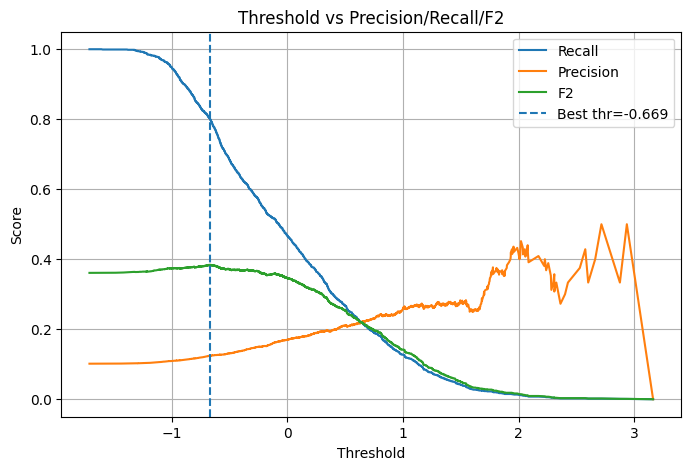

ROC_AUC:     0.6740993740147854
Accuracy:      0.4189543035729369
F1 score:      0.21229817931982137
Precision:     0.12226325507781588
Recall:        0.8053866203301477

Confusion matrix:

TN: 4033, FP: 6655, FN: 224, TP: 927

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.38      0.54     10688
           1       0.12      0.81      0.21      1151

    accuracy                           0.42     11839
   macro avg       0.53      0.59      0.38     11839
weighted avg       0.87      0.42      0.51     11839



In [22]:
svc_pipe.test()

# XGBoost

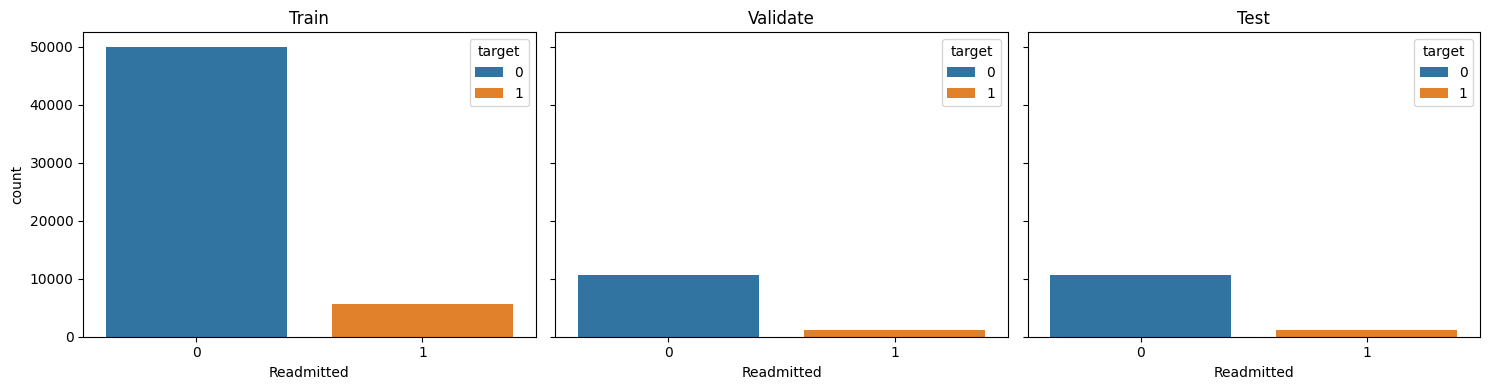

In [23]:
xgb_pipe = ModelPipeline(
    model='xgb',
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log=UPDATE_DATABASE,
    create_interactions=True,
    log_transform_cols=LOG_TRANSFORM_COLS
)

In [24]:
xgb_pipe.run_baseline()

--------SMOTE Baseline--------
roc_auc score per fold:  [0.621 0.611 0.6   0.62  0.606]
mean roc_auc score: , 0.612
-----Undersample Baseline-----
roc_auc score per fold:  [0.622 0.62  0.618 0.634 0.623]
mean roc_auc score: , 0.623
Duration: 0 hrs, 0 mins, 13.2 secs


,feature,importance_mean,importance_std
6,number_inpatient,0.064553,0.007837
7,number_diagnoses,0.004901,0.004007
1,num_lab_procedures,0.004720,0.002886
5,number_emergency,0.004370,0.001915
3,num_medications,0.003946,0.003038
59,i_hosp_time__diag1_group_circulatory,0.003080,0.001193
58,num_drugs,0.001973,0.000861
44,age_group_30-60,0.001460,0.000463
57,insulin_flag,0.001429,0.001221
51,admit_type_group_elective,0.001191,0.000664


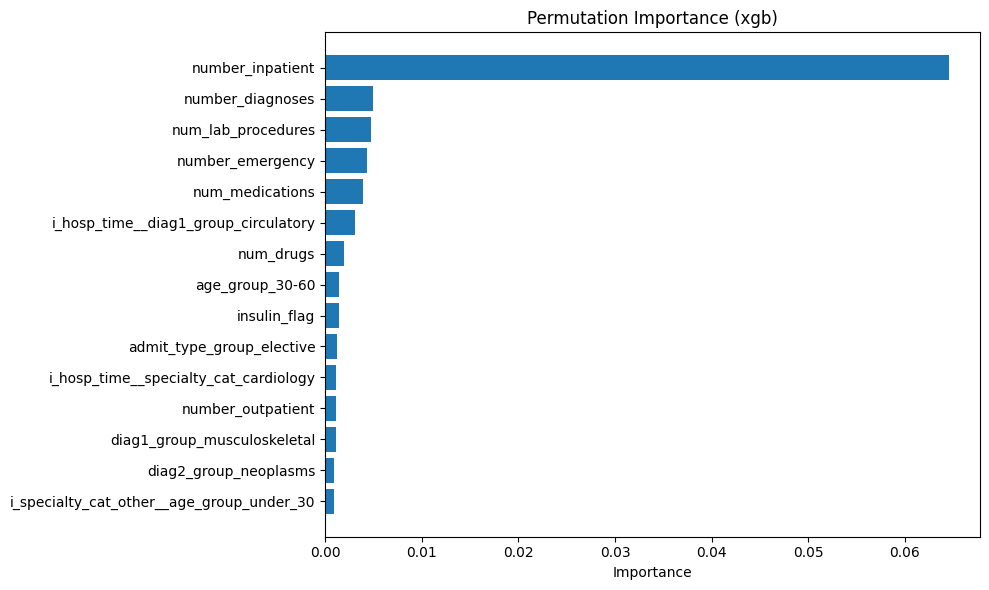

Duration: 0 hrs, 0 mins, 39.6 secs


In [25]:
xgb_pipe.permute_importance()

In [26]:
from scipy.stats import randint, uniform, loguniform

approx_spw = float(8.9494) # from data exploration aprox inverse of class balance


param_dist = {
    'model__n_estimators': randint(200, 1500),
    'model__learning_rate': uniform(0.01, 0.29),
    'model__max_depth': randint(2, 10),
    'model__min_child_weight': randint(1, 10),
    'model__subsample': uniform(0.5, 0.5),
    'model__colsample_bytree': uniform(0.5, 0.5),
    'model__gamma': uniform(0.0, 5.0),
    'model__reg_alpha': loguniform(1e-8, 1e-1),
    'model__reg_lambda': loguniform(1e-2, 10),
    'model__scale_pos_weight': loguniform(max(approx_spw/5, 1e-3), approx_spw*5),
}

xgb_pipe.run_hyperparam_search(
    hyperparam_dist=param_dist
)

Best ROC_AUC (cv): 0.6531053769061647
Best params: {'model__colsample_bytree': np.float64(0.702254063561095), 'model__gamma': np.float64(4.438850493804799), 'model__learning_rate': np.float64(0.2567692501425787), 'model__max_depth': 2, 'model__min_child_weight': 8, 'model__n_estimators': 303, 'model__reg_alpha': np.float64(0.0001757937447736795), 'model__reg_lambda': np.float64(0.010655924993232578), 'model__scale_pos_weight': np.float64(2.4812758281839526), 'model__subsample': np.float64(0.8317508845540279)}
logged hyperparameters
Duration: 0 hrs, 4 mins, 13.8 secs


In [27]:
xgb_pipe.validate()

Held out validation metrics: xgb
ROC_AUC:     0.6359843583233035
Accuracy:      0.19245314732330449
F1 score:      0.19394346111903363
Precision:     0.1079062820871838
Recall:        0.956953642384106

Confusion matrix:

TN: 1134, FP: 9557, FN: 52, TP: 1156

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.11      0.19     10691
           1       0.11      0.96      0.19      1208

    accuracy                           0.19     11899
   macro avg       0.53      0.53      0.19     11899
weighted avg       0.87      0.19      0.19     11899



Best threshold (F2): 0.6386
Precision: 0.128  Recall: 0.748  F2: 0.380


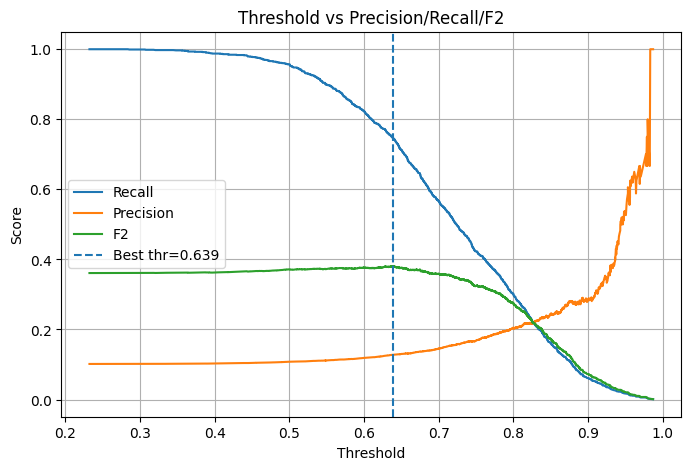

ROC_AUC:     0.6759632749054454
Accuracy:      0.47233719064110147
F1 score:      0.2203918632222638
Precision:     0.12867968522296708
Recall:        0.7671589921807124

Confusion matrix:

TN: 4709, FP: 5979, FN: 268, TP: 883

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.44      0.60     10688
           1       0.13      0.77      0.22      1151

    accuracy                           0.47     11839
   macro avg       0.54      0.60      0.41     11839
weighted avg       0.87      0.47      0.56     11839



In [28]:
xgb_pipe.test()